# Capstone 2: EmporiUm Sales/Marketing Analysis

## Author:
### Naomi Tewolde 

## Sales Territory: 
### Region: Northeast
### States: Maine & Massachusetts

## Bonus Question: 

## ----------------------------------------------------------------------------------

In [1]:
# Importing essential libraries for data analysis and visualization

import numpy as np        # for fast numerical computations
import pandas as pd      # for organizing and analyzing data in tables
import matplotlib.pyplot as plt  # for creating charts and visual insights
from sklearn.linear_model import LinearRegression # creates regression model

## Loading CSV Files: 
##### Store Sales, Store Detail, Product Categories, Customer List, & Products

In [2]:
store_detail = pd.read_csv("StoreDetail.csv") # Importing/loading data

store_detail.info() # confirms the column names, number of non-null records, and dtype for each column 

store_detail.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [3]:
store_sales = pd.read_csv("StoreSales.csv") # Importing/loading data

store_sales.info() # confirms the column names, number of non-null records, and dtype for each column

store_sales.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [4]:
products = pd.read_csv("Products.csv") # Importing/loading data

products.info() # confirms the column names, number of non-null records, and dtype for each column

products.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
customer_list = pd.read_csv("customer_list.csv") # Importing/loading data

customer_list.info() # confirms the column names, number of non-null records, and dtype for each column

customer_list.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [6]:
productcategories = pd.read_csv("productcategories.csv") # Importing/loading data

productcategories.info() # confirms the column names, number of non-null records, and dtype for each column

productcategories.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


## ----------------------------------------------------------------------------------

# Core Marketing Analysis: Bonus

## Q5:
### What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

### Deeper Insight

#### Question 1: what are the highest Revenue Products by State?

In [7]:
# merge sales + store + product info
sales_products = store_sales.merge(
    store_detail[['Store ID', 'State']],
    on='Store ID'
).merge(
    products[['Prod Num', 'Product']],
    on='Prod Num')

# filter for Maine & Massachusetts
territory_sales = sales_products[
    (sales_products['State'] == 'Maine') |
    (sales_products['State'] == 'Massachusetts')]

# group by State + Product
product_revenue = territory_sales.groupby(
    ['State', 'Product']
)['Sale Amount'].sum().reset_index()

# top 10 per state
top_products = product_revenue.sort_values(
    ['State', 'Sale Amount'], ascending=[True, False]
).groupby('State').head(10)

# display table
top_products

,State,Product,Sale Amount
6,Maine,ASUS VivoBook S15,47804.00
195,Maine,HP Pavilion 14,46867.68
359,Maine,MSI Creator Z16,44092.50
347,Maine,Lenovo Yoga 7i,41484.96
128,Maine,Dell XPS 13,40848.70
126,Maine,Dell Inspiron 15,39531.00
30,Maine,"Apple MacBook Pro (M2, 14-inch)",39507.10
194,Maine,HP Envy 15,37528.80
343,Maine,Lenovo IdeaPad Flex 5,36240.40
346,Maine,Lenovo ThinkPad X1 Carbon,35199.36


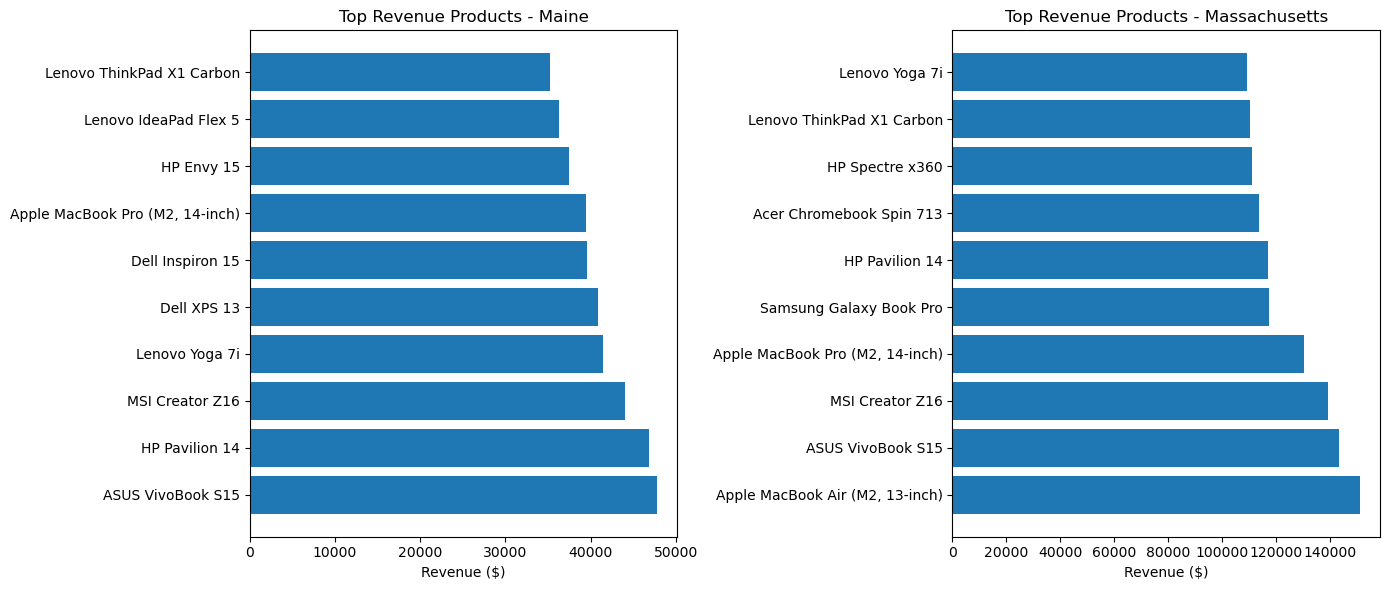

In [8]:
# separate states
maine_products = top_products[top_products['State'] == 'Maine']
mass_products = top_products[top_products['State'] == 'Massachusetts']

# create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Maine
axes[0].barh(maine_products['Product'], maine_products['Sale Amount'])
axes[0].set_title('Top Revenue Products - Maine')
axes[0].set_xlabel('Revenue ($)')

# Massachusetts
axes[1].barh(mass_products['Product'], mass_products['Sale Amount'])
axes[1].set_title('Top Revenue Products - Massachusetts')
axes[1].set_xlabel('Revenue ($)')

# display grapgh
plt.tight_layout()
plt.show()

## Key Findings:

### High-value technology products are likely the top revenue drivers in both states, indicating that premium-priced items contribute significantly to total sales. This reveals that all the top selling products are all in the Technology Product Category. Products with the highest transaction counts are not always the highest revenue generators, suggesting that some items are popular due to lower pricing, while others generate more revenue due to higher value.

## ----------------------------------------------------------------------------------